## Phenotype Plots

### Scattered PhasePlot

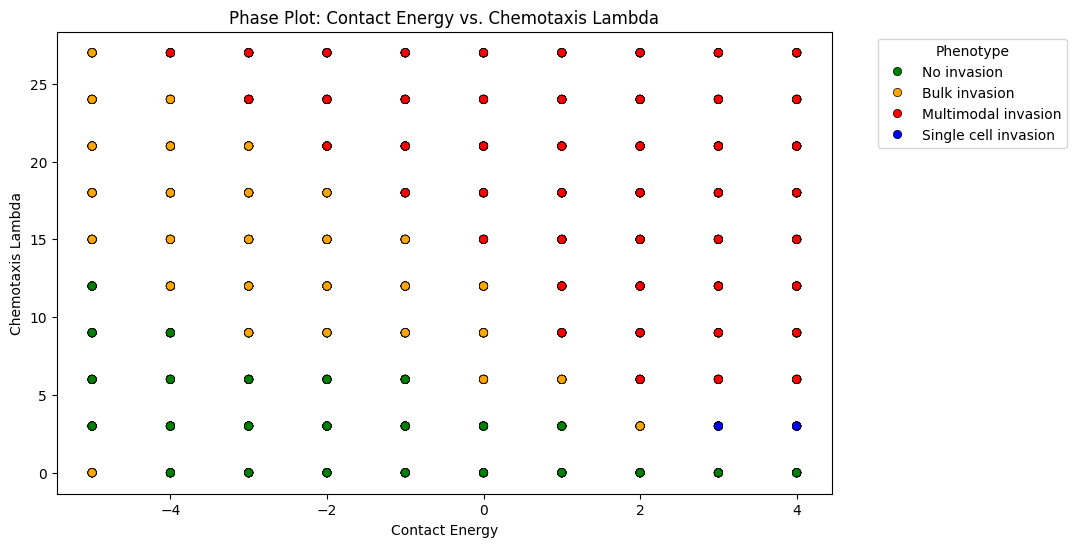

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/phenotypes.csv"  

df = pd.read_csv(file_path)

# Define custom color mapping for phenotypes (ensuring exact matches)
phenotype_colors = {
    "No invasion": "green",
    "Single cell invasion": "blue",
    "Bulk invasion": "orange",
    "Multimodal invasion": "red" 
}

# Ensure phenotype names match
df["Phenotype"] = df["Phenotype"].str.strip()

# Set plot size
plt.figure(figsize=(10, 6))

# Create a scatter plot with specified colors
sns.scatterplot(
    data=df,
    x="Contact Energy",
    y="Chemotaxis Lambda",
    hue="Phenotype",
    palette=phenotype_colors,
    edgecolor="black"
)

# Customize the plot
plt.xlabel("Contact Energy")
plt.ylabel("Chemotaxis Lambda")
plt.title("Phase Plot: Contact Energy vs. Chemotaxis Lambda")
plt.legend(title="Phenotype", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


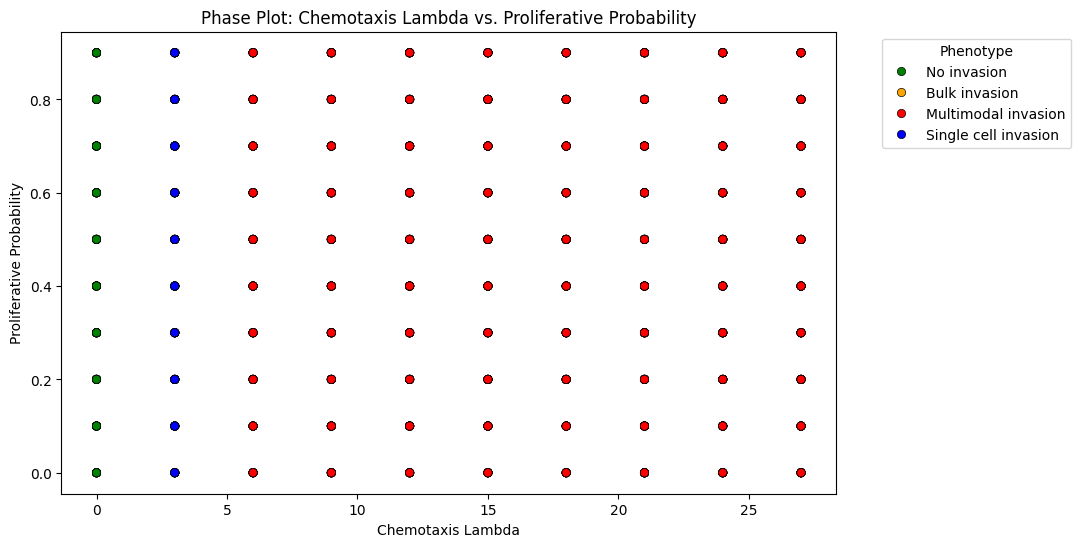

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path_latest= "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/phenotypes.csv"

df_latest = pd.read_csv(file_path_latest)

# Define custom color mapping for phenotypes
phenotype_colors_latest = {
     "No invasion": "green",
    "Single cell invasion": "blue",
    "Bulk invasion": "orange",
    "Multimodal invasion": "red" 
}

# Ensure phenotype names match by stripping any extra spaces
df_latest["Phenotype"] = df_latest["Phenotype"].str.strip()

# Set plot size
plt.figure(figsize=(10, 6))

# Create a scatter plot with specified colors
sns.scatterplot(
    data=df_latest,
    x="Chemotaxis Lambda",
    y="Proliferative Probability",
    hue="Phenotype",
    palette=phenotype_colors_latest,
    edgecolor="black"
)

# Customize the plot
plt.xlabel("Chemotaxis Lambda")
plt.ylabel("Proliferative Probability")
plt.title("Phase Plot: Chemotaxis Lambda vs. Proliferative Probability")
plt.legend(title="Phenotype", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


### 2d phase plot

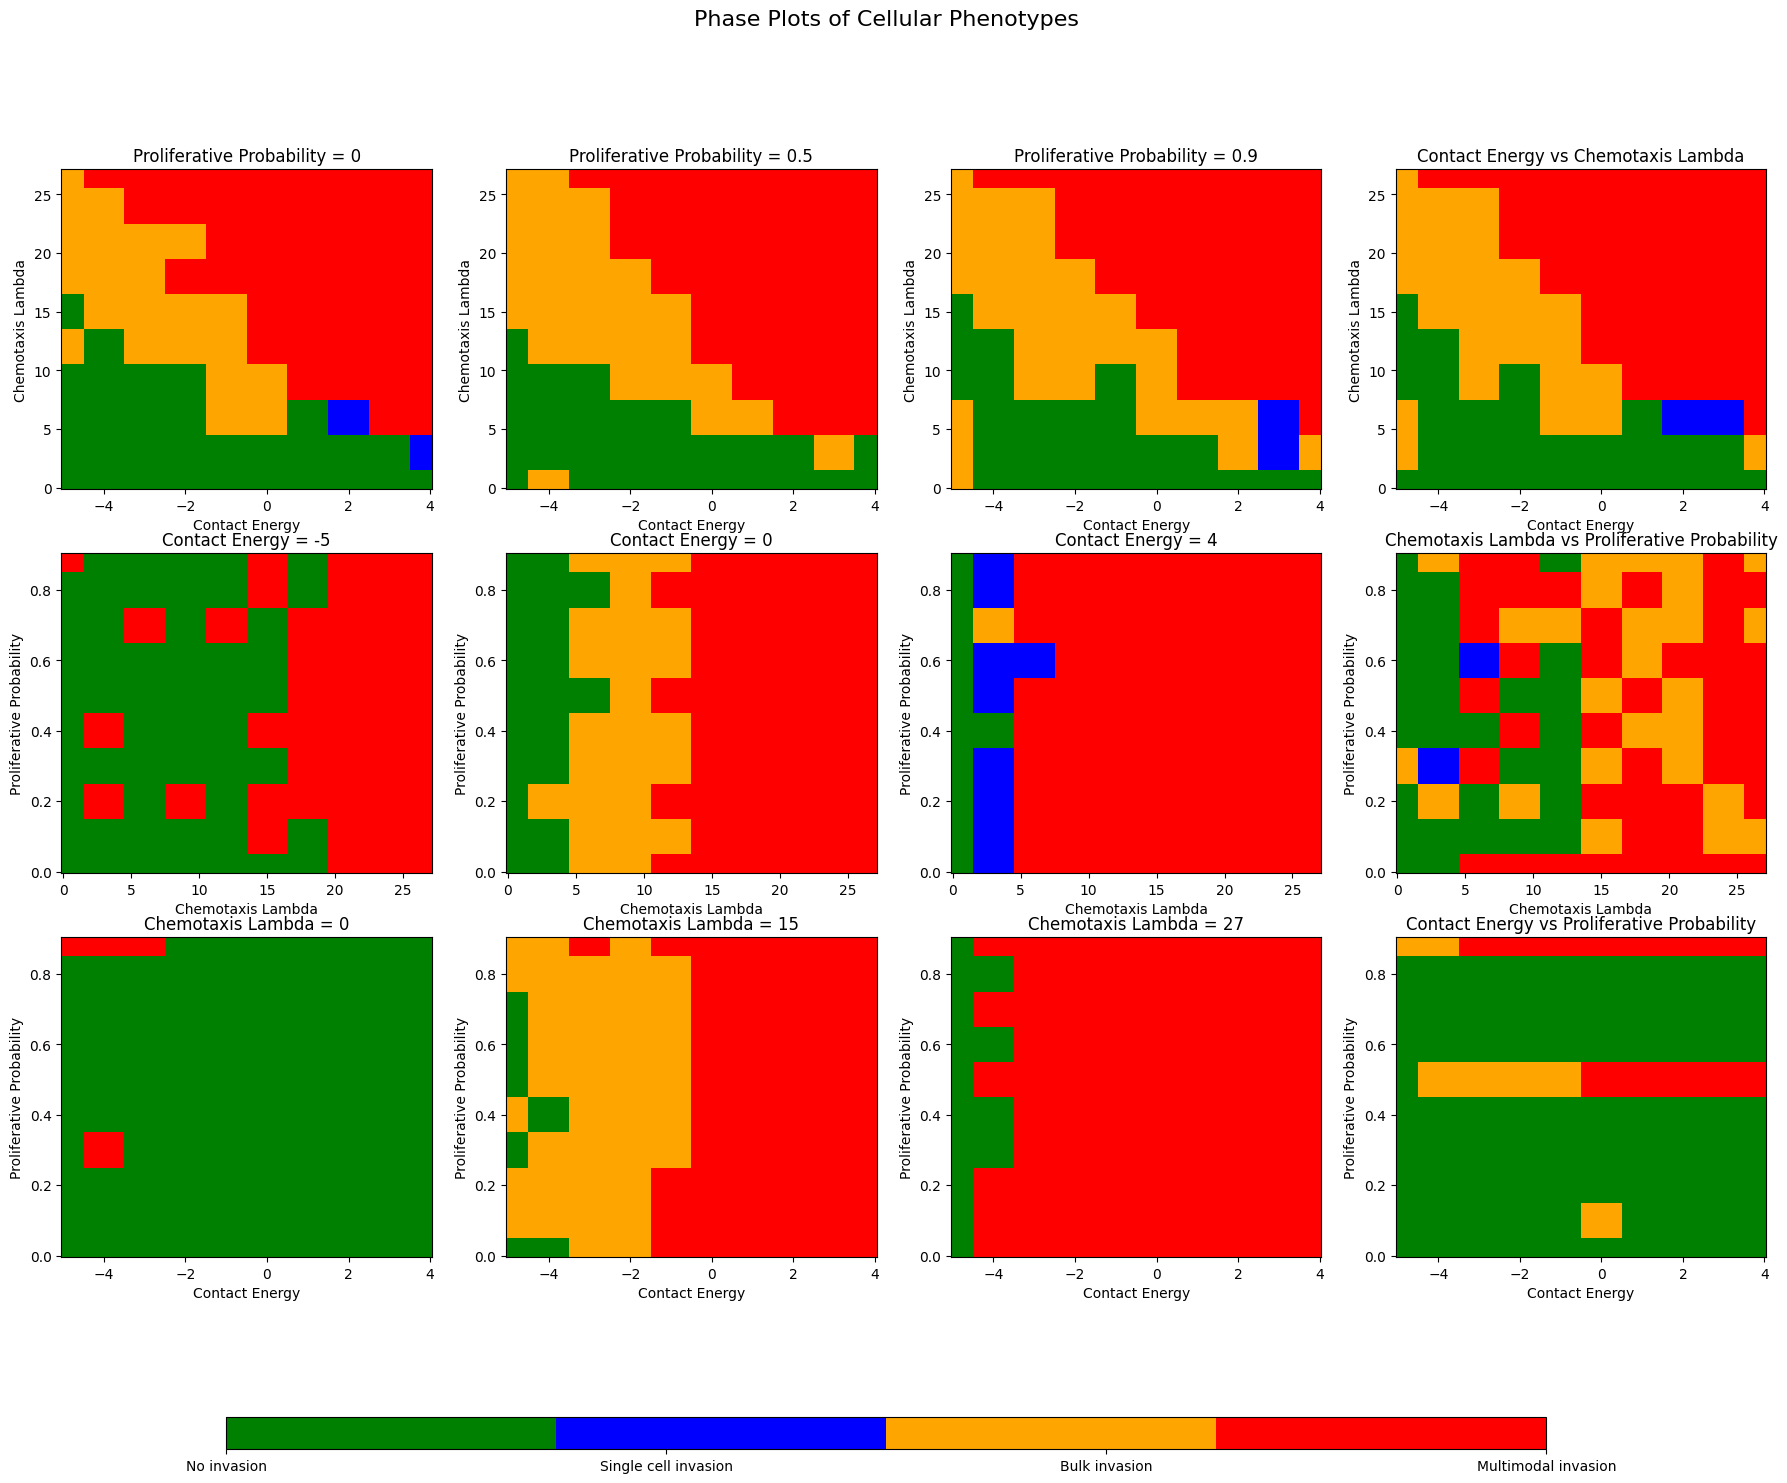

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import ListedColormap


file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/phenotypes.csv"
df = pd.read_csv(file_path)


phenotype_order = ["No invasion", "Single cell invasion", "Bulk invasion", "Multimodal invasion"]
phenotype_colors = {
    "No invasion": "green",
    "Single cell invasion": "blue",
    "Bulk invasion": "orange",
    "Multimodal invasion": "red"
}
ordered_colors = [phenotype_colors[phenotype] for phenotype in phenotype_order]
custom_cmap = ListedColormap(ordered_colors)

# Convert phenotype labels into numerical categories
df["Phenotype"] = pd.Categorical(df["Phenotype"], categories=phenotype_order, ordered=True)
df["Phenotype Category"] = df["Phenotype"].cat.codes

# Define subplot parameters
prolif_probs = [0, 0.5, 0.9]
contact_energy_values = [-5, 0, 4]
chemotaxis_lambda_values = [0, 15, 27]

# Create figure with a structured layout (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.suptitle("Phase Plots of Cellular Phenotypes", fontsize=16)

### --- ROW 1: Contact Energy vs Chemotaxis Lambda (for different Proliferative Probabilities) --- ###
for i, prob in enumerate(prolif_probs):
    df_subset = df[df["Proliferative Probability"] == prob]
    
    if not df_subset.empty:
        x_grid = np.linspace(df_subset["Contact Energy"].min(), df_subset["Contact Energy"].max(), 100)
        y_grid = np.linspace(df_subset["Chemotaxis Lambda"].min(), df_subset["Chemotaxis Lambda"].max(), 100)
        X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

        Z_grid = griddata(
            (df_subset["Contact Energy"], df_subset["Chemotaxis Lambda"]),
            df_subset["Phenotype Category"],
            (X_grid, Y_grid),
            method='nearest'
        )

        #axes[0, i].contourf(X_grid, Y_grid, Z_grid, levels=np.arange(-0.5, len(phenotype_order), 1), cmap=custom_cmap, alpha=0.6)
        axes[0, i].pcolormesh(X_grid, Y_grid, Z_grid, cmap=custom_cmap, shading='nearest')


    axes[0, i].set_xlabel("Contact Energy")
    axes[0, i].set_ylabel("Chemotaxis Lambda")
    axes[0, i].set_title(f"Proliferative Probability = {prob}")

# Overall plot for Contact Energy vs Chemotaxis Lambda (1,4)
x_grid = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), 100)
y_grid = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid_all = griddata(
    (df["Contact Energy"], df["Chemotaxis Lambda"]),
    df["Phenotype Category"],
    (X_grid, Y_grid),
    method='nearest'
)
#axes[0, 3].contourf(X_grid, Y_grid, Z_grid_all, levels=np.arange(-0.5, len(phenotype_order), 1), cmap=custom_cmap, alpha=0.6)
axes[0, 3].pcolormesh(X_grid, Y_grid, Z_grid_all, cmap=custom_cmap, shading='nearest')
axes[0, 3].set_xlabel("Contact Energy")
axes[0, 3].set_ylabel("Chemotaxis Lambda")
axes[0, 3].set_title("Contact Energy vs Chemotaxis Lambda")


### --- ROW 2: Chemotaxis Lambda vs Proliferative Probability (for different Contact Energy values) --- ###
for i, energy in enumerate(contact_energy_values):
    df_subset = df[df["Contact Energy"] == energy]
    
    if not df_subset.empty:
        x_grid = np.linspace(df_subset["Chemotaxis Lambda"].min(), df_subset["Chemotaxis Lambda"].max(), 100)
        y_grid = np.linspace(df_subset["Proliferative Probability"].min(), df_subset["Proliferative Probability"].max(), 100)
        X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

        Z_grid = griddata(
            (df_subset["Chemotaxis Lambda"], df_subset["Proliferative Probability"]),
            df_subset["Phenotype Category"],
            (X_grid, Y_grid),
            method='nearest'
        )

        axes[1, i].contourf(X_grid, Y_grid, Z_grid, levels=np.arange(-0.5, len(phenotype_order), 1), cmap=custom_cmap, alpha=0.6)
        axes[1, i].pcolormesh(X_grid, Y_grid, Z_grid, cmap=custom_cmap, shading='nearest')

    axes[1, i].set_xlabel("Chemotaxis Lambda")
    axes[1, i].set_ylabel("Proliferative Probability")
    axes[1, i].set_title(f"Contact Energy = {energy}")

x_grid = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), 100)
y_grid = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid_all = griddata(
    (df["Chemotaxis Lambda"], df["Proliferative Probability"]),
    df["Phenotype Category"],
    (X_grid, Y_grid),
    method='nearest'
)
# Overall plot for Chemotaxis Lambda vs Proliferative Probability (2,4)
#axes[1, 3].contourf(X_grid, Y_grid, Z_grid_all, levels=np.arange(-0.5, len(phenotype_order), 1), cmap=custom_cmap, alpha=0.6)
axes[1, 3].pcolormesh(X_grid, Y_grid, Z_grid_all, cmap=custom_cmap, shading='nearest')
axes[1, 3].set_xlabel("Chemotaxis Lambda")
axes[1, 3].set_ylabel("Proliferative Probability")
axes[1, 3].set_title("Chemotaxis Lambda vs Proliferative Probability")


### --- ROW 3: Contact Energy vs Proliferative Probability (for different Chemotaxis Lambda values) --- ###
for i, chemotaxis in enumerate(chemotaxis_lambda_values):
    df_subset = df[df["Chemotaxis Lambda"] == chemotaxis]
    
    if not df_subset.empty:
        x_grid = np.linspace(df_subset["Contact Energy"].min(), df_subset["Contact Energy"].max(), 100)
        y_grid = np.linspace(df_subset["Proliferative Probability"].min(), df_subset["Proliferative Probability"].max(), 100)
        X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

        Z_grid = griddata(
            (df_subset["Contact Energy"], df_subset["Proliferative Probability"]),
            df_subset["Phenotype Category"],
            (X_grid, Y_grid),
            method='nearest'
        )

        #axes[2, i].contourf(X_grid, Y_grid, Z_grid, levels=np.arange(-0.5, len(phenotype_order), 1), cmap=custom_cmap, alpha=0.6)
        axes[2, i].pcolormesh(X_grid, Y_grid, Z_grid, cmap=custom_cmap, shading='nearest')

    axes[2, i].set_xlabel("Contact Energy")
    axes[2, i].set_ylabel("Proliferative Probability")
    axes[2, i].set_title(f"Chemotaxis Lambda = {chemotaxis}")

x_grid = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), 100)
y_grid = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid_all = griddata(
    (df["Contact Energy"], df["Proliferative Probability"]),
    df["Phenotype Category"],
    (X_grid, Y_grid),
    method='nearest'
)
# Overall plot for Contact Energy vs Proliferative Probability (3,4)
#axes[2, 3].contourf(X_grid, Y_grid, Z_grid_all, levels=np.arange(-0.5, len(phenotype_order), 1), cmap=custom_cmap, alpha=0.6)
axes[2, 3].pcolormesh(X_grid, Y_grid, Z_grid_all, cmap=custom_cmap, shading='nearest')
axes[2, 3].set_xlabel("Contact Energy")
axes[2, 3].set_ylabel("Proliferative Probability")
axes[2, 3].set_title("Contact Energy vs Proliferative Probability")

fig.subplots_adjust(bottom=0.2) 
# Add colorbar
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.02])
cbar = fig.colorbar(axes[2, 3].collections[0], cax=cbar_ax, ticks=range(len(phenotype_order)), orientation="horizontal", fraction=0.05)
cbar.ax.set_xticklabels(phenotype_order)

plt.show()


## 2D Phenotype Plots

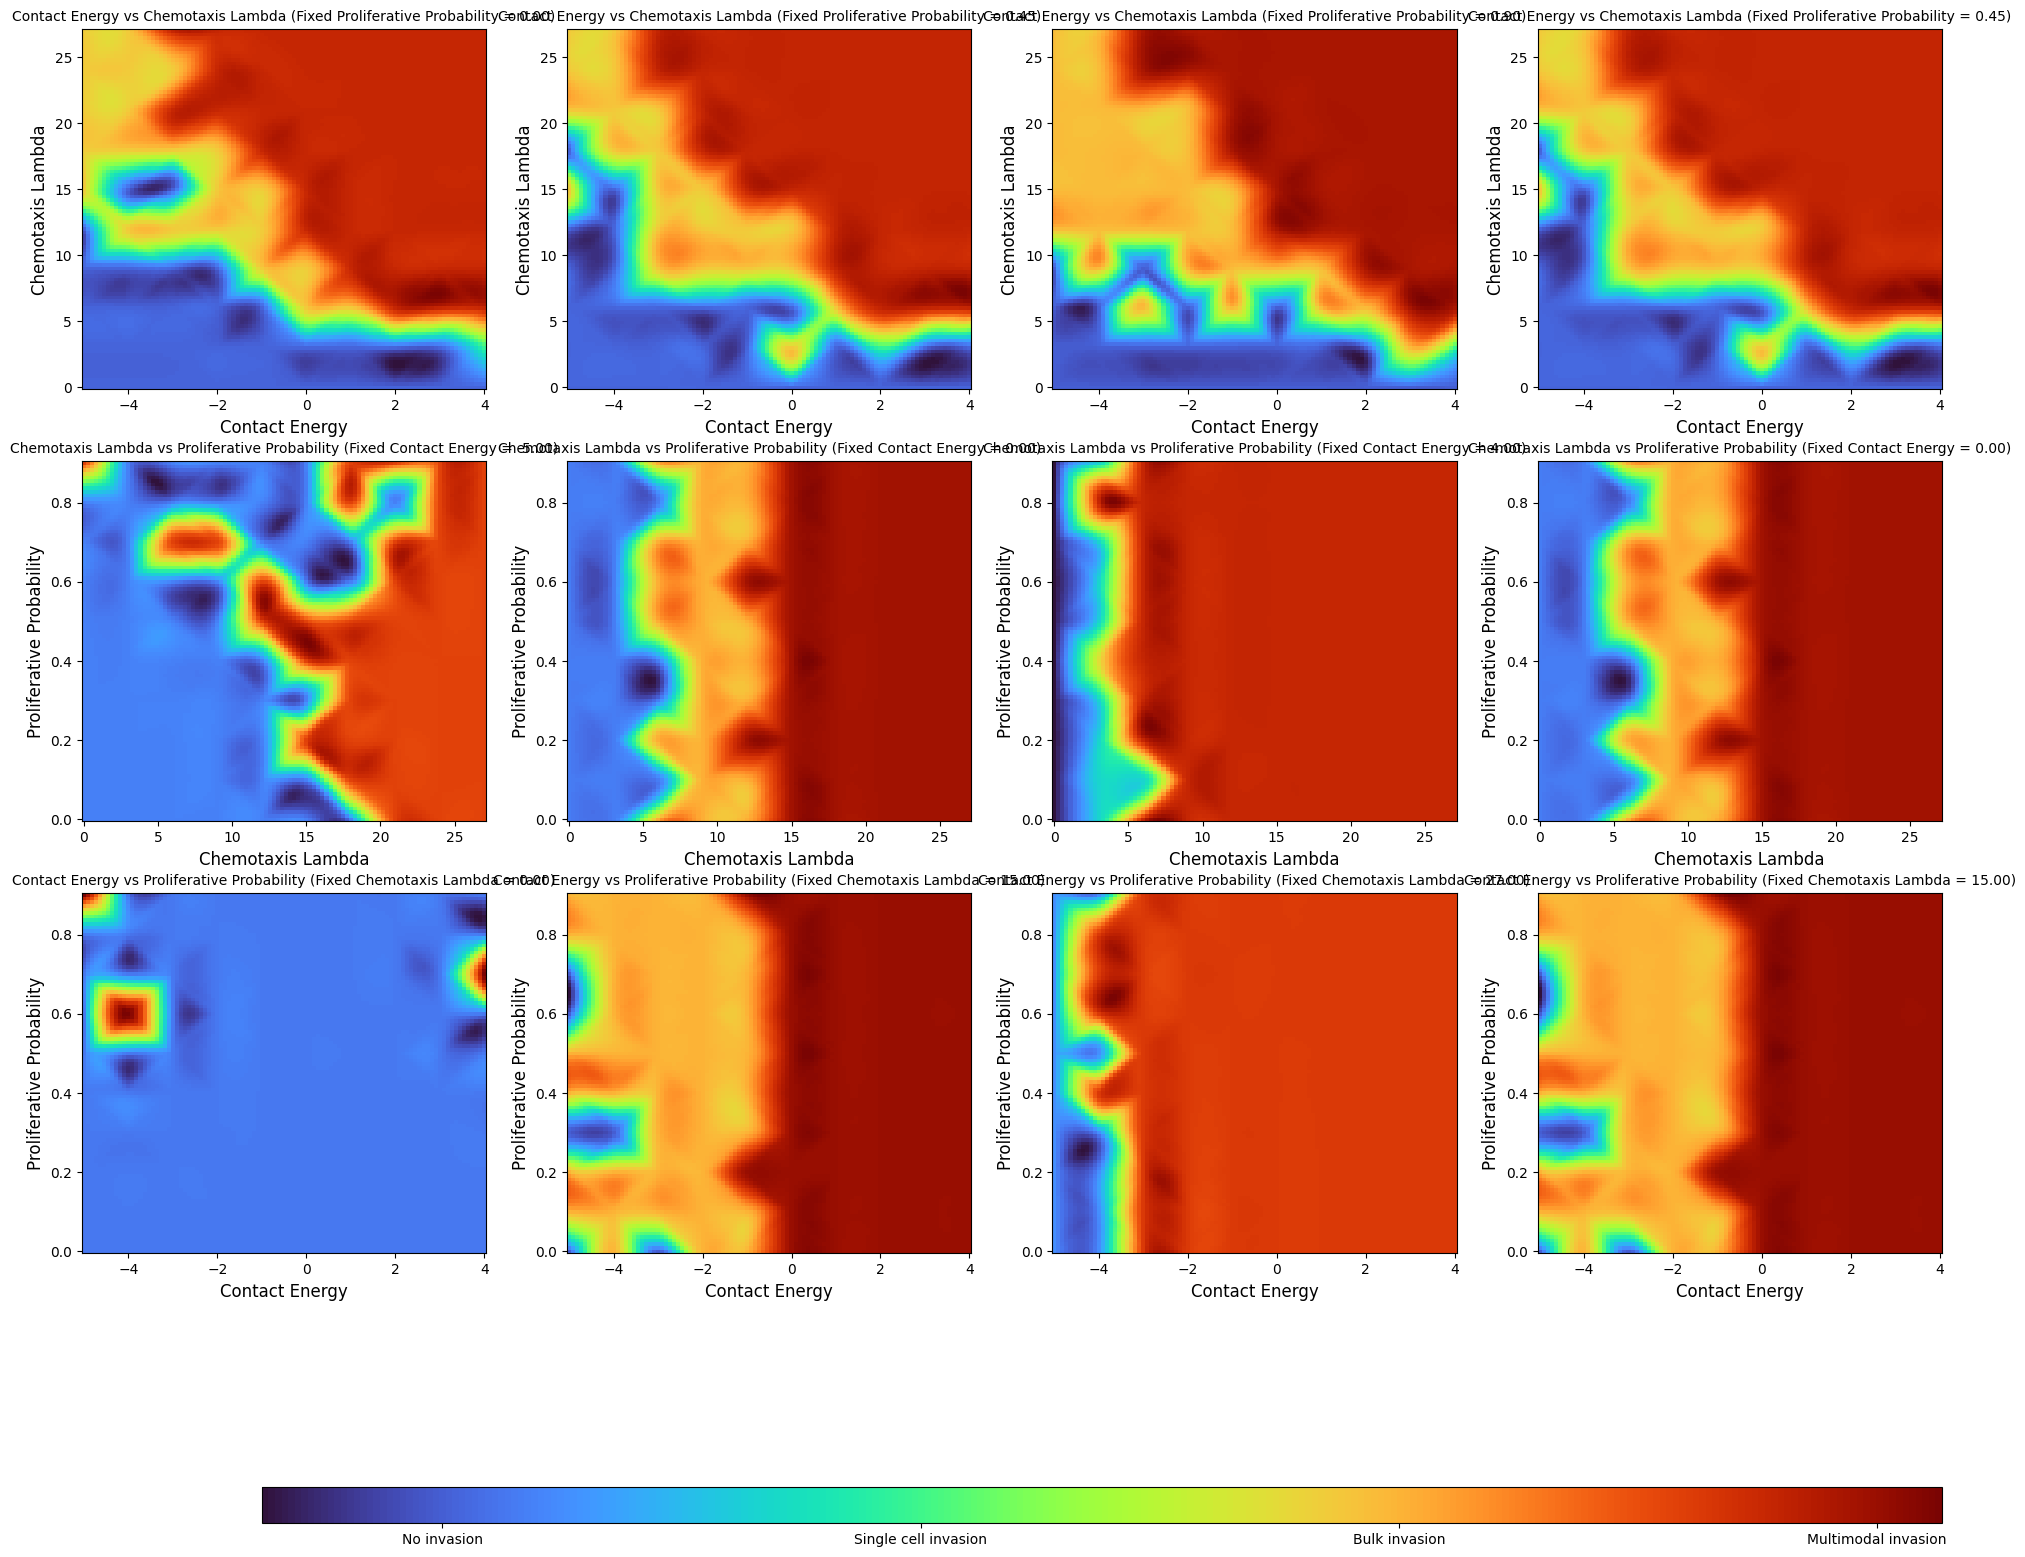

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.patches as mpatches

# Load dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/phenotypes.csv"
df = pd.read_csv(file_path)

# Define phenotype categories and colors
phenotype_order = ["No invasion", "Single cell invasion", "Bulk invasion", "Multimodal invasion"]
phenotype_colors = {
    "No invasion": "blue",
    "Single cell invasion": "green",
    "Bulk invasion": "yellow",
    "Multimodal invasion": "red"
}

# Map phenotypes to numerical categories
df["Phenotype"] = pd.Categorical(df["Phenotype"], categories=phenotype_order, ordered=True)
df["Phenotype Numeric"] = df["Phenotype"].cat.codes

# Extract variables
x = df["Contact Energy"].values
y = df["Chemotaxis Lambda"].values
z = df["Proliferative Probability"].values
c = df["Phenotype Numeric"].values  # Phenotype categories as numbers

# Define fixed values
x_half = 0
y_half = 15
z_half = np.median(df["Proliferative Probability"])

# Function to generate a smooth interpolated mesh grid
def plot_mesh_grid(ax, param1, param2, fixed_param, fixed_value, param1_label, param2_label):
    mask = np.isclose(df[fixed_param], fixed_value, atol=0.1)
    subset = df[mask]

    if subset.empty:
        return

    # Create mesh grid
    X, Y = np.meshgrid(
        np.linspace(subset[param1].min(), subset[param1].max(), 100),
        np.linspace(subset[param2].min(), subset[param2].max(), 100)
    )

    # Interpolate phenotype data
    Z = griddata((subset[param1], subset[param2]), subset["Phenotype Numeric"], (X, Y), method='cubic')

    # If cubic interpolation fails, use nearest
    if np.isnan(Z).all():
        Z = griddata((subset[param1], subset[param2]), subset["Phenotype Numeric"], (X, Y), method='nearest')

    # Plot using pcolormesh
    contour = ax.pcolormesh(X, Y, Z, cmap="turbo", shading='auto')

    # Set labels
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label} (Fixed {fixed_param} = {fixed_value:.2f})", fontsize=10)

    return contour

# Create figure and subplots
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

# Row 1: Contact Energy vs Chemotaxis Lambda (Fixed Proliferative Probability)
fixed_values = [df["Proliferative Probability"].min(), z_half, df["Proliferative Probability"].max()]
for i, val in enumerate(fixed_values):
    contour = plot_mesh_grid(axes[0, i], "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability", val, "Contact Energy", "Chemotaxis Lambda")

# Overall plot for Contact Energy vs Chemotaxis Lambda
contour = plot_mesh_grid(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability", z_half, "Contact Energy", "Chemotaxis Lambda")
#contour = plot_mesh_grid(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", None, None, "Contact Energy", "Chemotaxis Lambda")

# Row 2: Chemotaxis Lambda vs Proliferative Probability (Fixed Contact Energy)
fixed_values = [df["Contact Energy"].min(), x_half, df["Contact Energy"].max()]
for i, val in enumerate(fixed_values):
    contour = plot_mesh_grid(axes[1, i], "Chemotaxis Lambda", "Proliferative Probability", "Contact Energy", val, "Chemotaxis Lambda", "Proliferative Probability")

# Overall plot for Chemotaxis Lambda vs Proliferative Probability
contour = plot_mesh_grid(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", "Contact Energy", x_half, "Chemotaxis Lambda", "Proliferative Probability")
#contour = plot_mesh_grid(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", None, None, "Chemotaxis Lambda", "Proliferative Probability")

# Row 3: Contact Energy vs Proliferative Probability (Fixed Chemotaxis Lambda)
fixed_values = [df["Chemotaxis Lambda"].min(), y_half, df["Chemotaxis Lambda"].max()]
for i, val in enumerate(fixed_values):
    contour = plot_mesh_grid(axes[2, i], "Contact Energy", "Proliferative Probability", "Chemotaxis Lambda", val, "Contact Energy", "Proliferative Probability")

# Overall plot for Contact Energy vs Proliferative Probability
contour = plot_mesh_grid(axes[2, 3], "Contact Energy", "Proliferative Probability", "Chemotaxis Lambda", y_half, "Contact Energy", "Proliferative Probability")
#contour = plot_mesh_grid(axes[2, 3], "Contact Energy", "Proliferative Probability", None, None, "Contact Energy", "Proliferative Probability")



# Add colorbar
fig.subplots_adjust(bottom=0.2) 

cbar_ax = fig.add_axes([0.2, 0.05, 0.7, 0.02])
cbar = fig.colorbar(contour, cax=cbar_ax, orientation="horizontal", fraction=0.05)
cbar.set_ticks(range(len(phenotype_order)))
cbar.set_ticklabels(phenotype_order)

#plt.tight_layout()
plt.show()


### 3D Phase Plot

In [12]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from scipy.interpolate import griddata

file_path =  "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/phenotypes.csv"
df = pd.read_csv(file_path)

# Define phenotype categories and their colors
phenotype_order = ["No invasion", "Single cell invasion", "Bulk invasion", "Multimodal invasion"]
phenotype_colors = ["green", "blue", "yellow", "red"]

df["Phenotype"] = pd.Categorical(df["Phenotype"], categories=phenotype_order, ordered=True)
df["Phenotype Category"] = df["Phenotype"].cat.codes

# Create grid for interpolation
x_grid = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), 30)
y_grid = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), 30)
z_grid = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), 30)
X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)

# Interpolate phenotype values in 3D space
phenotype_grid = griddata(
    (df["Contact Energy"], df["Chemotaxis Lambda"], df["Proliferative Probability"]),
    df["Phenotype Category"],
    (X, Y, Z),
    method='nearest'
)

# Define the color mapping for the phenotypes
phenotype_colorscale = [
    [0.0, "green"],   # No invasion
    [0.33, "blue"],   # Single cell invasion
    [0.66, "orange"],  # Bulk invasion
    [1, "red"],    # Multimodal invasion
    #[1.0, "red"]
]
#phenotype_colorscale = go.colors.ColorScale(phenotype_colorscale)

# Create interactive 3D plot
fig = go.Figure()

fig.add_trace(go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=phenotype_grid.flatten(),
    opacity=0.5,  # Adjust transparency
    surface_count=20,  # Number of contour surfaces
    colorscale=phenotype_colorscale,  # Apply phenotype-specific colors
    colorbar=dict(
        title="Phenotype",
        tickvals=[0, 1, 2, 3],
        ticktext=phenotype_order
    )
))

fig.update_layout(
    title="3D Interactive Plot: Contact Energy vs. Chemotaxis Lambda vs. Proliferative Probability",
    scene=dict(
        xaxis_title="Contact Energy",
        yaxis_title="Chemotaxis Lambda",
        zaxis_title="Proliferative Probability"
    )
)

# Show plot
fig.show()


In [92]:
pip install -U kaleido


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 65.6 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [95]:
pip install imageio

Note: you may need to restart the kernel to use updated packages.


In [98]:
 pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [99]:
import plotly.io as pio
pio.kaleido.scope


In [4]:
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
import numpy as np
import imageio
import os
from scipy.interpolate import griddata

# Load the dataset
file_path =  "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/phenotypes.csv"
df = pd.read_csv(file_path)

# Define phenotype categories and their colors
phenotype_order = ["No invasion", "Single cell invasion", "Bulk invasion", "Multimodal invasion"]
phenotype_colors = ["green", "blue", "yellow", "red"]

df["Phenotype"] = pd.Categorical(df["Phenotype"], categories=phenotype_order, ordered=True)
df["Phenotype Category"] = df["Phenotype"].cat.codes

# Create grid for interpolation
x_grid = np.linspace(df["Contact Energy"].min(), df["Contact Energy"].max(), 30)
y_grid = np.linspace(df["Chemotaxis Lambda"].min(), df["Chemotaxis Lambda"].max(), 30)
z_grid = np.linspace(df["Proliferative Probability"].min(), df["Proliferative Probability"].max(), 30)
X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)

# Interpolate phenotype values in 3D space
phenotype_grid = griddata(
    (df["Contact Energy"], df["Chemotaxis Lambda"], df["Proliferative Probability"]),
    df["Phenotype Category"],
    (X, Y, Z),
    method='linear'
)

# Define the color mapping for the phenotypes
phenotype_colorscale = [
    [0.0, "green"],   # No invasion
    [0.25, "blue"],   # Single cell invasion
    [0.5, "yellow"],  # Bulk invasion
    [0.75, "red"],    # Multimodal invasion
    [1.0, "red"]
]

# Create a directory for frames
frames_dir = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/frames"
os.makedirs(frames_dir, exist_ok=True)

# Generate frames with different angles
num_frames = 36
image_files = []

for i, angle in enumerate(np.linspace(0, 360, num_frames)):
    fig = go.Figure()

    fig.add_trace(go.Volume(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=phenotype_grid.flatten(),
        opacity=0.5,
        surface_count=20,
        colorscale=phenotype_colorscale,
        colorbar=dict(
            title="Phenotype",
            tickvals=[0, 1, 2, 3],
            ticktext=phenotype_order
        )
    ))

    fig.update_layout(
        title="3D Interactive Plot: Contact Energy vs. Chemotaxis Lambda vs. Proliferative Probability",
        scene=dict(
            xaxis_title="Contact Energy",
            yaxis_title="Chemotaxis Lambda",
            zaxis_title="Proliferative Probability",
            camera=dict(
                eye=dict(x=np.cos(np.radians(angle)) * 2,  # Increase zoom out factor
                        y=np.sin(np.radians(angle)) * 2,  # Increase zoom out factor
                        z=1.5)  # Increase z value to zoom out
            )
        )
    )

    frame_path = os.path.join(frames_dir, f"frame_{i:03d}.png")
    pio.write_image(fig, frame_path, format="png", scale=2)
    image_files.append(frame_path)

# Create a GIF from frames
gif_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/3D_plot.gif"
with imageio.get_writer(gif_path, mode='I', duration=0.1) as writer:
    for image_file in image_files:
        writer.append_data(imageio.imread(image_file))

# Return GIF path
gif_path


/var/folders/jr/3tw1qcls4879795w5933hkj00000gn/T/ipykernel_31692/4083590947.py:91: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.



'/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/3D_plot.gif'